In [60]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

In [61]:
df = pd.read_excel('cancer_prediction.xlsx')

In [62]:
df

,Patient_ID,Age,BMI,Smoking,Family_History,Alcohol_Use,Physical_Activity_Hours_Week,Blood_Pressure,Glucose,Cholesterol,WBC,Hemoglobin,Platelets,Tumor_Size_cm,Cell_Abnormality_Score,Genetic_Risk_Score,Cancer
0,P00001,64,24.9,0,0,0,2.4,125,151.0,260.0,5.78,12.76,274,6.71,29.6,13.7,0
1,P00002,56,24.7,0,0,0,2.4,146,134.0,156.0,8.55,11.40,450,3.53,12.4,42.7,0
2,P00003,66,18.0,0,0,1,5.2,123,127.0,197.0,8.65,15.92,300,3.76,51.3,28.4,0
3,P00004,78,25.3,0,0,1,4.5,150,100.0,188.0,8.48,12.83,328,0.73,14.6,34.2,0
4,P00005,55,30.7,0,0,0,5.1,155,131.0,218.0,6.92,NaN,206,1.62,30.1,19.1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,P04996,57,33.5,1,0,0,5.6,119,72.0,208.0,4.50,8.84,313,5.25,1.7,14.3,0
4996,P04997,67,17.0,1,1,0,3.2,121,114.0,243.0,9.13,11.14,317,0.71,11.1,51.5,1
4997,P04998,90,23.5,0,0,0,4.4,125,97.0,188.0,7.18,14.51,363,4.28,68.5,30.3,0
4998,P04999,69,29.5,0,1,0,4.4,144,99.0,248.0,2.72,16.51,311,1.93,43.2,49.7,1


In [63]:
df.shape

(5000, 17)

In [64]:
df.describe()

,Age,BMI,Smoking,Family_History,Alcohol_Use,Physical_Activity_Hours_Week,Blood_Pressure,Glucose,Cholesterol,WBC,Hemoglobin,Platelets,Tumor_Size_cm,Cell_Abnormality_Score,Genetic_Risk_Score,Cancer
count,5000.000000,4850.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,4850.000000,4850.000000,4850.000000,4850.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,58.066000,26.971753,0.379400,0.293400,0.346200,3.508840,131.762200,108.040206,205.389278,7.018703,13.487470,260.104800,3.963544,35.377720,30.198720,0.266800
std,12.804501,5.003423,0.485286,0.455366,0.475805,1.725802,17.883266,27.438088,39.453743,1.969185,1.801407,70.533303,2.661003,17.495766,17.269372,0.442331
min,25.000000,15.000000,0.000000,0.000000,0.000000,0.000000,90.000000,60.000000,100.000000,2.000000,7.530000,80.000000,0.200000,1.000000,0.000000,0.000000
25%,49.000000,23.600000,0.000000,0.000000,0.000000,2.300000,119.000000,88.000000,178.000000,5.682500,12.280000,213.000000,1.980000,23.000000,17.575000,0.000000
50%,58.000000,26.900000,0.000000,0.000000,0.000000,3.500000,132.000000,107.000000,206.000000,7.030000,13.480000,261.000000,3.400000,35.100000,30.000000,0.000000
75%,67.000000,30.400000,1.000000,1.000000,1.000000,4.700000,144.000000,127.000000,232.000000,8.350000,14.690000,309.000000,5.330000,47.500000,42.200000,1.000000
max,90.000000,44.600000,1.000000,1.000000,1.000000,9.300000,198.000000,212.000000,346.000000,13.760000,18.000000,500.000000,15.000000,100.000000,100.000000,1.000000


In [65]:
df.duplicated().sum()

np.int64(0)

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Patient_ID                    5000 non-null   object 
 1   Age                           5000 non-null   int64  
 2   BMI                           4850 non-null   float64
 3   Smoking                       5000 non-null   int64  
 4   Family_History                5000 non-null   int64  
 5   Alcohol_Use                   5000 non-null   int64  
 6   Physical_Activity_Hours_Week  5000 non-null   float64
 7   Blood_Pressure                5000 non-null   int64  
 8   Glucose                       4850 non-null   float64
 9   Cholesterol                   4850 non-null   float64
 10  WBC                           4850 non-null   float64
 11  Hemoglobin                    4850 non-null   float64
 12  Platelets                     5000 non-null   int64  
 13  Tum

In [67]:
print(df['Cancer'].value_counts())

Cancer
0    3666
1    1334
Name: count, dtype: int64


In [68]:
print(df["Cancer"].value_counts(normalize=True)*100)

Cancer
0    73.32
1    26.68
Name: proportion, dtype: float64


In [70]:
#check missing values
print(df.isnull().sum())

Patient_ID                        0
Age                               0
BMI                             150
Smoking                           0
Family_History                    0
Alcohol_Use                       0
Physical_Activity_Hours_Week      0
Blood_Pressure                    0
Glucose                         150
Cholesterol                     150
WBC                             150
Hemoglobin                      150
Platelets                         0
Tumor_Size_cm                     0
Cell_Abnormality_Score            0
Genetic_Risk_Score                0
Cancer                            0
dtype: int64


In [71]:
missing = df.isnull().sum()
missing_percentage = (missing/len(df))*100

In [81]:
missing_table = pd.DataFrame({
    "Missing": missing,
    "Percentage": missing_percentage
})

print(missing_table)

                              Missing  Percentage
Patient_ID                          0         0.0
Age                                 0         0.0
BMI                               150         3.0
Smoking                             0         0.0
Family_History                      0         0.0
Alcohol_Use                         0         0.0
Physical_Activity_Hours_Week        0         0.0
Blood_Pressure                      0         0.0
Glucose                           150         3.0
Cholesterol                       150         3.0
WBC                               150         3.0
Hemoglobin                        150         3.0
Platelets                           0         0.0
Tumor_Size_cm                       0         0.0
Cell_Abnormality_Score              0         0.0
Genetic_Risk_Score                  0         0.0
Cancer                              0         0.0


In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Age                           5000 non-null   int64  
 1   BMI                           4850 non-null   float64
 2   Smoking                       5000 non-null   int64  
 3   Family_History                5000 non-null   int64  
 4   Alcohol_Use                   5000 non-null   int64  
 5   Physical_Activity_Hours_Week  5000 non-null   float64
 6   Blood_Pressure                5000 non-null   int64  
 7   Glucose                       4850 non-null   float64
 8   Cholesterol                   4850 non-null   float64
 9   WBC                           4850 non-null   float64
 10  Hemoglobin                    4850 non-null   float64
 11  Platelets                     5000 non-null   int64  
 12  Tumor_Size_cm                 5000 non-null   float64
 13  Cel

In [74]:
x = df.drop('Cancer', axis=1)
y=df['Cancer']

In [75]:
print(x.shape)
print(y.shape)

(5000, 15)
(5000,)


In [103]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify=y
)

In [105]:
#simple imputer
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)

In [106]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [107]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(x_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [108]:
y_pred = log_model.predict(x_test_scaled)
print(y_pred[:20])

[0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 0 0 0]


In [109]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:",accuracy)

Accuracy: 0.768


In [120]:
from sklearn.metrics import(
accuracy_score, r2_score, precision_score, recall_score,
roc_auc_score)
print("Accuracy Score",accuracy_score(y_test,y_pred))
print("R2 Score",r2_score(y_test,y_pred))
print("Precision Score",precision_score(y_test,y_pred))
print("Roc Auc Score",roc_auc_score(y_test,y_pred))

Accuracy Score 0.768
R2 Score -0.1854213610885438
Precision Score 0.6174496644295302
Roc Auc Score 0.6334033345085355


In [126]:
#ROC-AUC Score
y_prob = log_model.predict_proba(x_test_scaled)[:,1]
auc = roc_auc_score(y_test, y_pred)
print("ROC_AUC",auc)

ROC_AUC 0.6334033345085355


In [128]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[676  57]
 [175  92]]


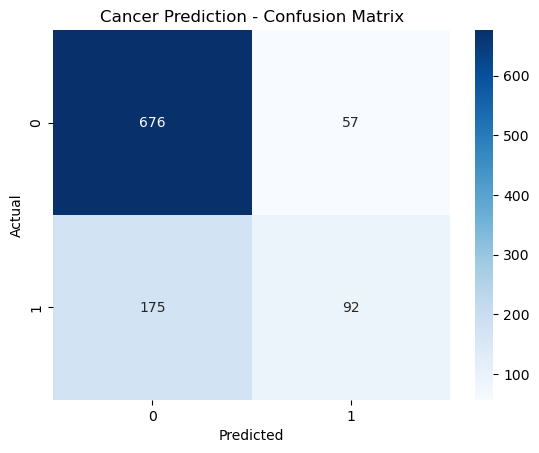

In [131]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Cancer Prediction - Confusion Matrix")
plt.show()

In [178]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree.fit(x_train, y_train)
tree_pred = tree.predict(x_test)

In [179]:
print("Accuracy:",accuracy_score(y_test, tree_pred))
print("R2_score:",r2_score(y_test, tree_pred))
print("Precision_Score:",precision_score(y_test, tree_pred))
print("Recall:",recall_score(y_test,tree_pred))
print("F1_Score:",f1_score(y_test,tree_pred))

Accuracy: 0.748
R2_score: -0.28761285773410794
Precision_Score: 0.5974025974025974
Recall: 0.17228464419475656
F1_Score: 0.26744186046511625


In [180]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(x_train, y_train)
rf_pred = rf.predict(x_test)

In [181]:
print("Accuracy Score:",accuracy_score(y_test, y_pred))
print("R2 Score:",r2_score(y_test, y_pred))
print("Precision Score:",precision_score(y_test, y_pred))
print("F1 Score",f1_score(y_test, y_pred))

Accuracy Score: 0.768
R2 Score: -0.1854213610885438
Precision Score: 0.6174496644295302
F1 Score 0.4423076923076923


In [182]:
rf.fit(x_train, y_train)#
rf_prob = rf.predict_proba(x_test)[:, 1]

print(
    "ROC-AUC:",
    roc_auc_score(y_test, rf_prob)
)

ROC-AUC: 0.7270388480974499


In [183]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(x_train, y_train)
xgb_pred = xgb.predict(x_test)

In [185]:
from sklearn.metrics import recall_score
print("Accuracy Score:",accuracy_score(y_test, xgb_pred))
print("Precision Score:",precision_score(y_test, xgb_pred))
print("R2 Score:",r2_score(y_test, xgb_pred))
print("F1 Score:",f1_score(y_test, xgb_pred))
print("Recall:",recall_score(y_test, xgb_pred))

Accuracy Score: 0.755
Precision Score: 0.5714285714285714
R2 Score: -0.2518458339081604
F1 Score: 0.4180522565320665
Recall: 0.3295880149812734


In [186]:
xgb_prob = xgb.predict_proba(x_test)[:,1]

print(
    "ROC-AUC:",
    roc_auc_score(y_test, xgb_prob)
)

ROC-AUC: 0.735472201358125


In [191]:
models = {
    "Logistic Regression": log_model,
    "Decision Tree": tree,
    "Random Forest": rf,
    "XGBoost": xgb
}

results = []

for name, model in models.items():

    if name == "Logistic Regression":
        x_eval = x_test_scaled
    else:
        x_eval = x_test

    pred = model.predict(x_eval)
    prob = model.predict_proba(x_eval)[:,1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall":recall_score(y_test, pred),
        "F1 Score":f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, prob)
    })

    results_df = pd.DataFrame(results)
    print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression     0.768    0.61745  0.344569  0.442308  0.757832
                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression     0.768   0.617450  0.344569  0.442308  0.757832
1        Decision Tree     0.748   0.597403  0.172285  0.267442  0.681926
                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression     0.768   0.617450  0.344569  0.442308  0.757832
1        Decision Tree     0.748   0.597403  0.172285  0.267442  0.681926
2        Random Forest     0.761   0.642857  0.235955  0.345205  0.727039
                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression     0.768   0.617450  0.344569  0.442308  0.757832
1        Decision Tree     0.748   0.597403  0.172285  0.267442  0.681926
2        Random Forest     0.761   0.642857  0.235955  0.345205  0.727039
3              XGBoost     0.755   0.5